### Data preparation

In [ ]:
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical

In [15]:
train_folder_path = "./train"
filenames = os.listdir(train_folder_path)

labels = []
for filename in filenames:
  if filename.split(".")[0] == 'cat':
    labels.append(1)
  else:
    labels.append(0)

df = pd.DataFrame({'filename': filenames,
                   'label' : labels})

df.head()

,filename,label
0,cat.0.jpg,1
1,cat.1.jpg,1
2,cat.10.jpg,1
3,cat.100.jpg,1
4,cat.1000.jpg,1


In [16]:
df['label'].value_counts()

label
1    12500
0    12500
Name: count, dtype: int64

In [19]:
df['label'] = df['label'].map( {0: 'dog', 1: 'cat'} )

In [20]:
train_df, test_df = train_test_split(df,
                                     test_size= 0.2,
                                     random_state=42)
train_df = train_df.reset_index(drop = True)
test_df = test_df.reset_index(drop = True)

train_size = train_df.shape[0]
test_size = test_df.shape[0]
batch_size = 200

In [21]:
train_datagen = ImageDataGenerator(rotation_range= 15, 
                                  rescale= 1/255,
                                  shear_range= 0.1,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  width_shift_range = 0.1,
                                  height_shift_range=0.1)

train_generator = train_datagen.flow_from_dataframe(train_df, 
                                                   train_folder_path,
                                                   x_col = 'filename', 
                                                   y_col = 'label',
                                                   target_size = (width, height),
                                                   class_mode = 'categorical')

Found 20000 validated image filenames belonging to 2 classes.


In [22]:
test_datagen = ImageDataGenerator(rescale = 1/255)

test_generator = test_datagen.flow_from_dataframe(test_df, 
                                                   train_folder_path,
                                                   x_col = 'filename', 
                                                   y_col = 'label', 
                                                   target_size = (width, height),
                                                   class_mode = 'categorical', 
                                                   batch_size=batch_size)

Found 5000 validated image filenames belonging to 2 classes.


In [23]:
example_df = train_df.sample(n = 1).reset_index(drop=True)
example_gen = train_datagen.flow_from_dataframe(example_df, 
                                                   train_folder_path,
                                                   x_col = 'filename', 
                                                   y_col = 'label', 
                                                   target_size = (width, height),
                                                   class_mode = 'categorical')

Found 1 validated image filenames belonging to 1 classes.


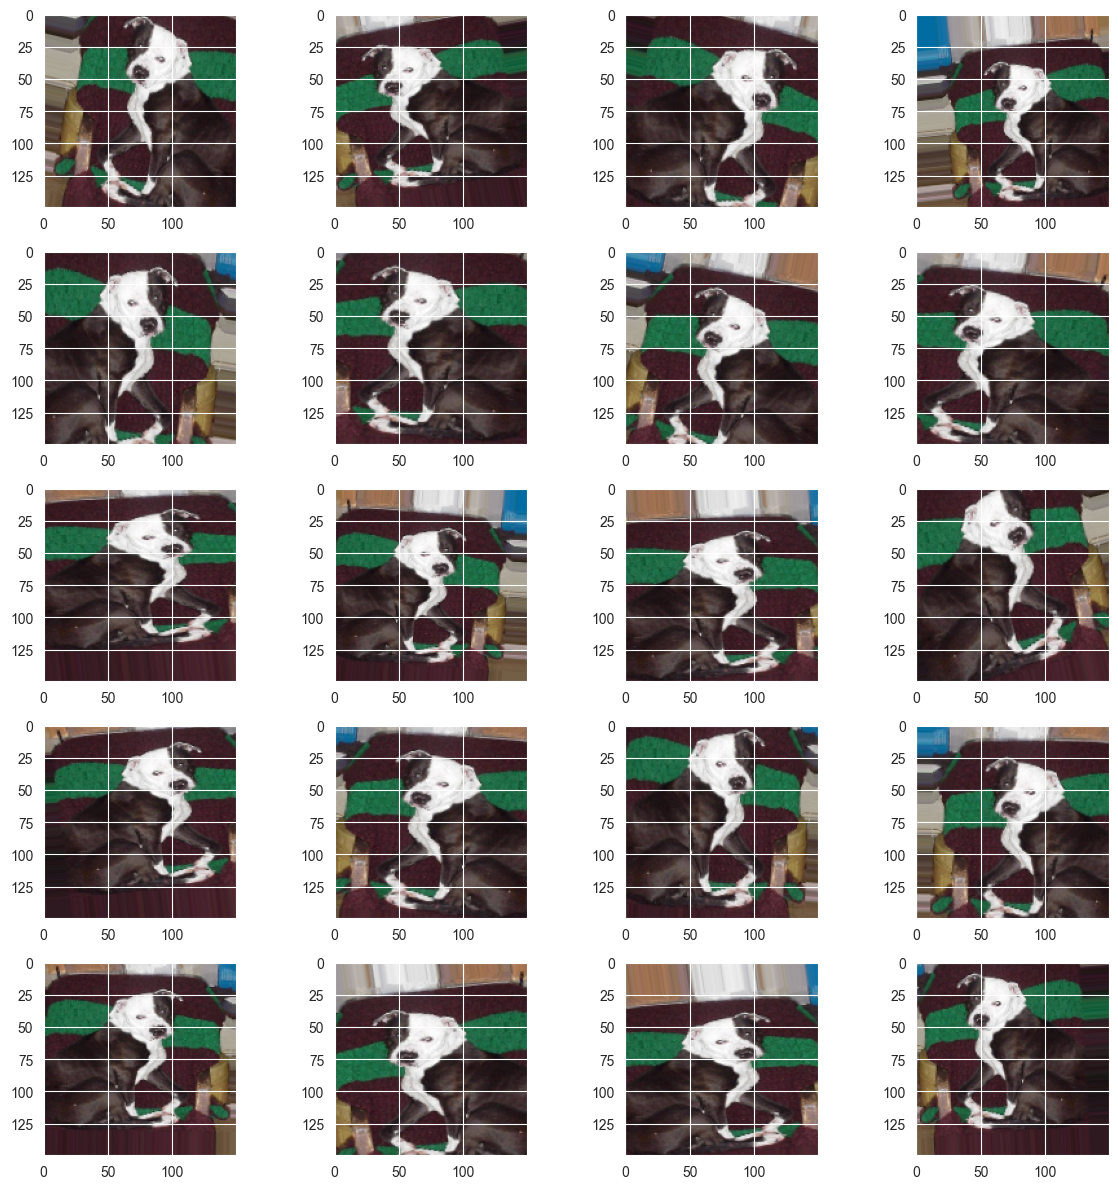

In [24]:
plt.figure(figsize = (12, 12))
for i in range(0, 20):
    plt.subplot(5, 4, i+1)
    for x_batch, y_batch in example_gen:
        img = x_batch[0]
        plt.imshow(img)
        break
plt.tight_layout()

### CNN using keras Sequential

In [12]:
import sys
import keras
import tensorflow as tf
import numpy as np

print(f"Tensor Flow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print()
print(f"Python {sys.version}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print(gpu)
print("GPU is", "available" if gpu else "NOT AVAILABLE")

Tensor Flow Version: 2.14.0
Keras Version: 2.14.0

Python 3.10.4 (tags/v3.10.4:9d38120, Mar 23 2022, 23:13:41) [MSC v.1929 64 bit (AMD64)]
False
GPU is NOT AVAILABLE


In [14]:
import pandas as pd

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [17]:
# width, height = 150, 150
#
# model = Sequential()
#
# # 1st convolutional layer
# model.add(Conv2D(32, (3,3),
#                  activation='relu',
#                  input_shape=(width,height,3)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size = (2,2)))
# model.add(Dropout(0.25))
#
# # 2nd convolutional layer
# model.add(Conv2D(64, (3,3), activation = 'relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size = (2, 2)))
# model.add(Dropout(0.25))
#
# # 3rd convolutional layer
# model.add(Conv2D(128, (3,3), activation = 'relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size = (2, 2)))
# model.add(Dropout(0.25))
#
# # dense layer
# model.add(Flatten()) # input layer
# model.add(Dense(512, activation = 'relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.25))
#
# # output layer
# model.add(Dense(2, activation = 'sigmoid'))
#
#
# model.compile(optimizer = 'adam',
#               loss = 'binary_crossentropy',
#               metrics = ['accuracy'])
# model.summary()

width, height = 64, 64

model = Sequential()

# 1st convolutional layer
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(width, height, 3)))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 2nd convolutional layer
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 3rd convolutional layer
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Dense layer
model.add(Flatten())
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(Dropout(0.25))

# Output layer
model.add(Dense(2, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 batch_normalization_4 (Bat  (None, 148, 148, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 74, 74, 32)        0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 74, 74, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 batch_normalization_5 (Bat  (None, 72, 72, 64)       

In [18]:
# reducing the learning rate when then accuracy does not increase for 2 steps
earlystop = EarlyStopping(patience=15)

lr_reduction = ReduceLROnPlateau(monitor = 'val_accuracy',
                                 patience = 2,
                                 verbose = 1,
                                 factor = 0.5,
                                 min_lr = 0.00001)
callbacks = [earlystop, lr_reduction]

In [25]:
fast = True
epochs = 5 if fast else 30

history = model.fit(train_generator,
                    epochs = epochs,
                    validation_data=test_generator,
                    validation_steps=test_size//batch_size,
                    steps_per_epoch=train_size//batch_size,
                    callbacks = callbacks)

Epoch 1/5
100/100 [==============================] - 122s 1s/step - loss: 0.8406 - accuracy: 0.5962 - val_loss: 0.9570 - val_accuracy: 0.5234 - lr: 0.0010
Epoch 2/5
100/100 [==============================] - 118s 1s/step - loss: 0.7271 - accuracy: 0.6187 - val_loss: 0.7612 - val_accuracy: 0.5100 - lr: 0.0010
Epoch 3/5
100/100 [==============================] - 112s 1s/step - loss: 0.6499 - accuracy: 0.6534 - val_loss: 0.6588 - val_accuracy: 0.6230 - lr: 0.0010
Epoch 4/5
100/100 [==============================] - 135s 1s/step - loss: 0.6272 - accuracy: 0.6591 - val_loss: 0.6230 - val_accuracy: 0.6566 - lr: 0.0010
Epoch 5/5
100/100 [==============================] - 147s 1s/step - loss: 0.6042 - accuracy: 0.6869 - val_loss: 0.6714 - val_accuracy: 0.6090 - lr: 0.0010


<Axes: >

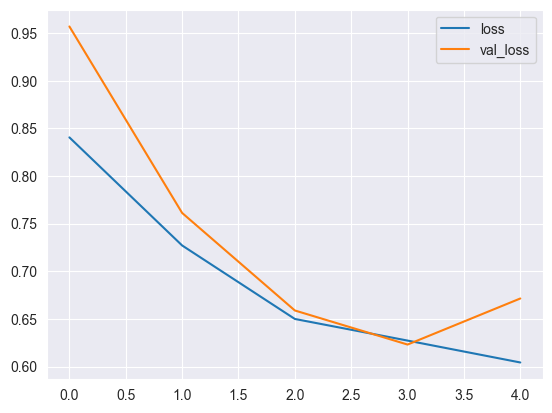

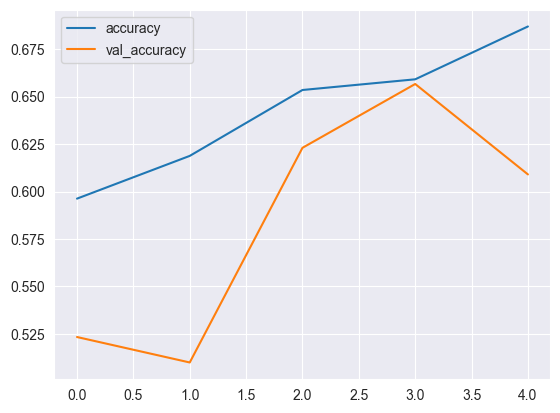

In [26]:
history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

### Pre-Trained ResNet-50

In [ ]:
from tensorflow.python.keras.applications import ResNet50

resnet50_model = Sequential()
resnet50_model.add(ResNet50(include_top=False,
                            pooling='max',
                            weights='imagenet'))
resnet50_model.add(Dense(2, activation='softmax'))
# ResNet-50 model is already trained, should not be trained
resnet50_model.layers[0].trainable = True

resnet50_model.compile(optimizer='sgd',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

resnet50_model.summary()

### VGG16

In [ ]:
from keras import layers
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation,GlobalMaxPooling2D
from keras import optimizers
from keras.applications import VGG16
from keras.models import Model

image_size = 224
input_shape = (image_size, image_size, 3)

epochs = 5
batch_size = 16

pre_trained_model = VGG16(input_shape=input_shape, include_top=False, weights="imagenet")

for layer in pre_trained_model.layers[:15]:
    layer.trainable = False

for layer in pre_trained_model.layers[15:]:
    layer.trainable = True

last_layer = pre_trained_model.get_layer('block5_pool')
last_output = last_layer.output

# Flatten the output layer to 1 dimension
x = GlobalMaxPooling2D()(last_output)
# Add a fully connected layer with 512 hidden units and ReLU activation
x = Dense(512, activation='relu')(x)
# Add a dropout rate of 0.5
x = Dropout(0.5)(x)
# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = Model(pre_trained_model.input, x)

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.SGD(lr=1e-4, momentum=0.9),
              metrics=['accuracy'])

model.summary()